In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("01-2023.csv")
df1 = pd.read_csv("02-2023.csv")
df2 = pd.read_csv("03-2023.csv")
df3 = pd.read_csv("04-2023.csv")
df4 = pd.read_csv("05-2023.csv")

In [5]:
df = pd.concat([df, df1, df2, df3, df4], ignore_index=True)

In [7]:
df

,Record ID,Activity date,Call direction,Call duration,hs_call_outcome,Activity assigned to
0,29440312866,2023-01-01 12:00,NaN,00:02:06,NaN,Ray Levesque
1,29444061847,2023-01-01 16:42,NaN,NaN,NaN,David Banister
2,29444240240,2023-01-01 16:48,NaN,NaN,NaN,David Banister
3,29444260139,2023-01-01 16:54,NaN,NaN,NaN,David Banister
4,29444240665,2023-01-01 16:57,NaN,NaN,NaN,David Banister
...,...,...,...,...,...,...
41556,35497445988,2023-05-31 20:12,NaN,00:00:42,NaN,Adrian Tran
41557,35503815706,2023-05-31 20:37,NaN,00:00:28,NaN,Adrian Tran
41558,35507832834,2023-05-31 20:50,NaN,00:08:15,NaN,Vladimir Suparto
41559,35504424093,2023-05-31 21:06,NaN,00:01:46,NaN,Vladimir Suparto


In [9]:
df1 = df.drop(columns = ['hs_call_outcome', 'Record ID'])

In [11]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 41561 entries, 0 to 41560
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Activity date         41561 non-null  str  
 1   Call direction        1550 non-null   str  
 2   Call duration         37657 non-null  str  
 3   Activity assigned to  41549 non-null  str  
dtypes: str(4)
memory usage: 2.7 MB


In [15]:
df1['Activity date'] = pd.to_datetime(
    df1['Activity date'],
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)

# Call Count per day

In [18]:
df2 = df1.copy()

In [20]:
df2['date'] = df2['Activity date'].dt.date

In [22]:
df2.head()

,Activity date,Call direction,Call duration,Activity assigned to,date
0,2023-01-01 12:00:00,NaN,00:02:06,Ray Levesque,2023-01-01
1,2023-01-01 16:42:00,NaN,NaN,David Banister,2023-01-01
2,2023-01-01 16:48:00,NaN,NaN,David Banister,2023-01-01
3,2023-01-01 16:54:00,NaN,NaN,David Banister,2023-01-01
4,2023-01-01 16:57:00,NaN,NaN,David Banister,2023-01-01


In [24]:
daily_calls = (
    df2.groupby(df2['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

In [143]:
daily_calls.tail()

Activity date
2023-05-27     14
2023-05-28      1
2023-05-29    198
2023-05-30    437
2023-05-31    514
dtype: int64

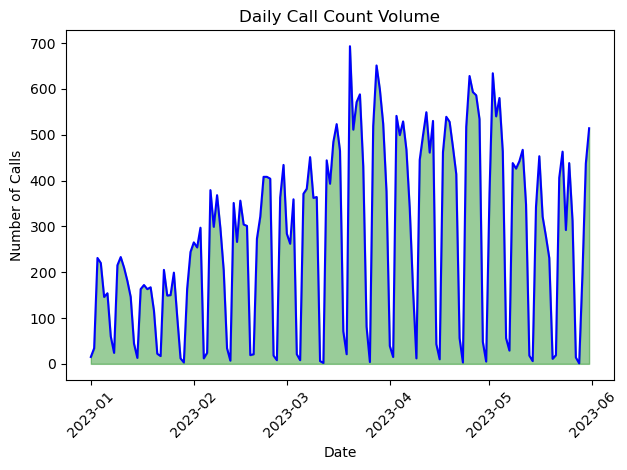

In [28]:
plt.figure()
plt.plot(daily_calls['date'], daily_calls['call_count'], color= 'blue')

plt.fill_between(daily_calls['date'], daily_calls['call_count'], color = 'green', alpha=0.4)

plt.title("Daily Call Count Volume")
plt.xlabel("Date")
plt.ylabel("Number of Calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
df1.head()

,Activity date,Call direction,Call duration,Activity assigned to
0,2023-01-01 12:00:00,NaN,00:02:06,Ray Levesque
1,2023-01-01 16:42:00,NaN,NaN,David Banister
2,2023-01-01 16:48:00,NaN,NaN,David Banister
3,2023-01-01 16:54:00,NaN,NaN,David Banister
4,2023-01-01 16:57:00,NaN,NaN,David Banister


# Count of Call in Weekdays

In [33]:
df1['day'] = df1['Activity date'].dt.day_name()

In [37]:
df1.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2023-01-01 12:00:00,NaN,00:02:06,Ray Levesque,Sunday
1,2023-01-01 16:42:00,NaN,NaN,David Banister,Sunday
2,2023-01-01 16:48:00,NaN,NaN,David Banister,Sunday
3,2023-01-01 16:54:00,NaN,NaN,David Banister,Sunday
4,2023-01-01 16:57:00,NaN,NaN,David Banister,Sunday


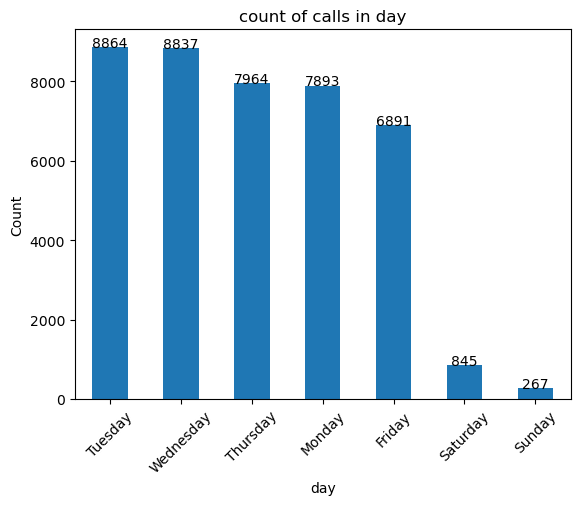

In [39]:
day_Counts = df1["day"].value_counts()
day_Counts.plot(kind='bar')
ax = day_Counts.plot(kind='bar')

for i,v in enumerate(day_Counts):
    ax.text(i,v+1, str(v), ha= "center")

plt.title("count of calls in day")
plt.xlabel("day")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Inbound VS Outbound

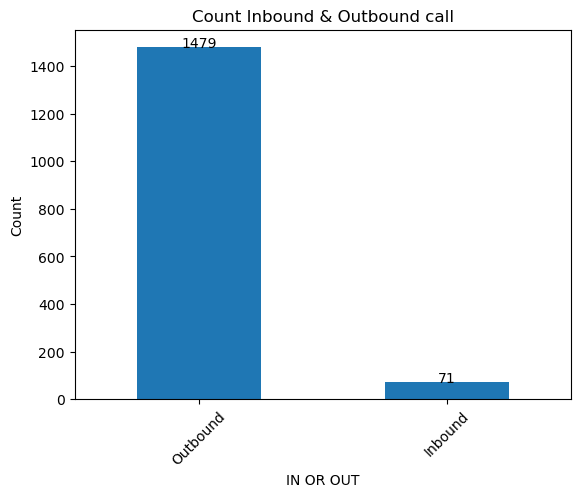

In [42]:
IN_OUT_COUNT = df1['Call direction'].value_counts()
IN_OUT_COUNT.plot(kind='bar')
ax = IN_OUT_COUNT.plot(kind='bar')

for i,v in enumerate(IN_OUT_COUNT):
    ax.text(i,v+1, str(v), ha="center")

plt.title("Count Inbound & Outbound call")
plt.xlabel('IN OR OUT')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Count 00 Duration for Bound

In [45]:
N_B = df1[(df1['Call duration'] == "00:00:00")]

IndexError: index 0 is out of bounds for axis 0 with size 0

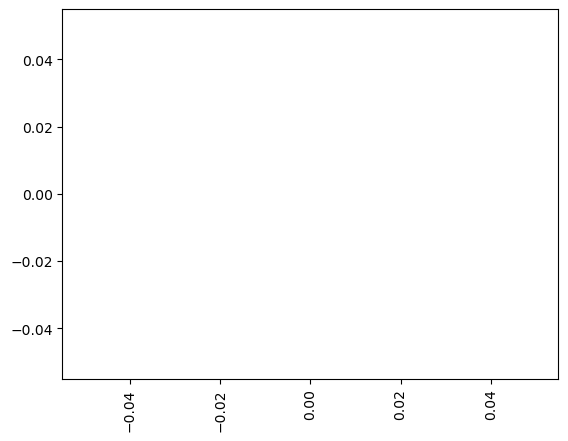

In [47]:
N_B_Counts = N_B['Call direction'].value_counts()
N_B_Counts.plot(kind="bar")
ax = N_B_Counts.plot(kind="bar")

for i,v in enumerate(N_B_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("Count 00 Duration for Bound")
plt.xlabel("Bound")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Call duration NULL but have Call direction

In [50]:
df1[(df1['Call duration'].isnull()) & (df1['Call direction'].notnull())]

,Activity date,Call direction,Call duration,Activity assigned to,day
70,2023-01-03 11:28:00,Outbound,NaN,Keith Antonio,Tuesday
71,2023-01-03 11:29:00,Outbound,NaN,Keith Antonio,Tuesday
72,2023-01-03 11:31:00,Outbound,NaN,Keith Antonio,Tuesday
73,2023-01-03 11:33:00,Outbound,NaN,Keith Antonio,Tuesday
74,2023-01-03 11:35:00,Outbound,NaN,Keith Antonio,Tuesday
...,...,...,...,...,...
40726,2023-05-30 13:13:00,Outbound,NaN,Keith Antonio,Tuesday
40729,2023-05-30 13:23:00,Outbound,NaN,Keith Antonio,Tuesday
40731,2023-05-30 13:26:00,Outbound,NaN,Keith Antonio,Tuesday
41146,2023-05-31 12:26:00,Outbound,NaN,Keith Antonio,Wednesday


In [52]:
df4 = df1.copy()

In [54]:
df4.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2023-01-01 12:00:00,NaN,00:02:06,Ray Levesque,Sunday
1,2023-01-01 16:42:00,NaN,NaN,David Banister,Sunday
2,2023-01-01 16:48:00,NaN,NaN,David Banister,Sunday
3,2023-01-01 16:54:00,NaN,NaN,David Banister,Sunday
4,2023-01-01 16:57:00,NaN,NaN,David Banister,Sunday


In [56]:
df4['Call duration'] = (
    pd.to_timedelta(df4['Call duration'], errors = 'coerce')
    .dt.total_seconds()/60
)

In [58]:
(df4['Call duration'] == 0).sum()

0

In [60]:
df4['Call duration'].isnull().sum()

3904

In [62]:
df4.info()

<class 'pandas.DataFrame'>
RangeIndex: 41561 entries, 0 to 41560
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         41561 non-null  datetime64[us]
 1   Call direction        1550 non-null   str           
 2   Call duration         37657 non-null  float64       
 3   Activity assigned to  41549 non-null  str           
 4   day                   41561 non-null  str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 2.4 MB


In [64]:
df4['Call duration'] = df4['Call duration'].fillna(0)

In [66]:
df4 = df4.dropna(subset = ['Call direction'])

In [68]:
df4['Call duration'].isnull().sum()

0

In [70]:
df4['Call direction'].isnull().sum()

0

In [72]:
(df4['Call duration'] == 0).sum()

293

In [74]:
df4.info()

<class 'pandas.DataFrame'>
Index: 1550 entries, 33 to 41476
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         1550 non-null   datetime64[us]
 1   Call direction        1550 non-null   str           
 2   Call duration         1550 non-null   float64       
 3   Activity assigned to  1550 non-null   str           
 4   day                   1550 non-null   str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 114.7 KB


# Working Call Assigner

In [77]:
df1['Activity assigned to'].nunique()

30

In [79]:
df1['Activity assigned to'].unique()

<ArrowStringArray>
[          'Ray Levesque',         'David Banister',         'Travis Fleming',
              'Terry Kim',         'Cameron Dudley',           'Dioni Canega',
                      nan,            'Paol Guzman',          'Keith Antonio',
          'Tommie Walker',       'Vladimir Suparto',            'Jinky Rance',
           'Karen Parker',       'Chrystel Manabat',        'Adonis Baybayan',
       'Kent Encarnacion',             'Henry Good',           'Bill Goodwin',
         'Branden Newman',           'John Meersma',             'Jacob Hess',
            'Adrian Tran',         'Justin Schmidt',           'David Valdez',
           'Andy Ramirez',           'Stephen Tarr',        'Ra’Saan Daniels',
    'Demmie Rose Tamonan',             'Daniel Uli',        'Justin Bellware',
 'Jannica Nikka Antipuna']
Length: 31, dtype: str

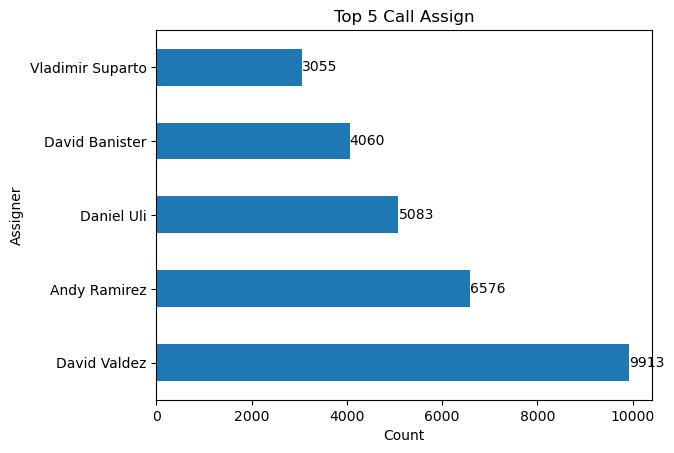

In [81]:
ASSI_COUNT = df1['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# MAX CALL DURATION

In [84]:
df4['Call duration'].max()

118.58333333333333

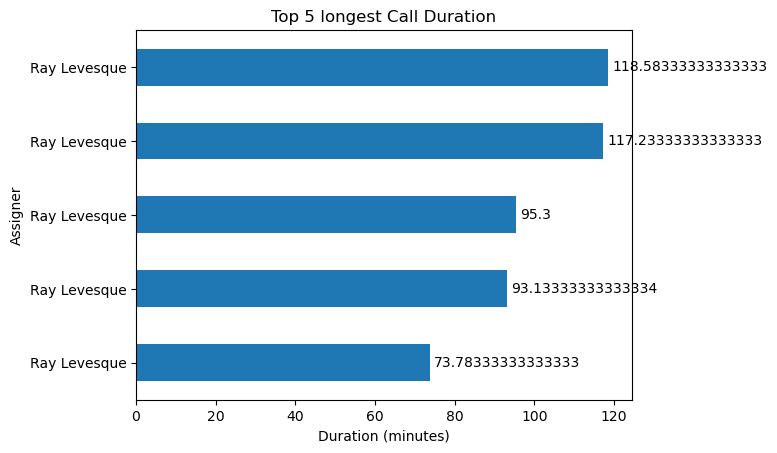

In [86]:
top5 = df4.nlargest(5, "Call duration")

ax = top5.set_index('Activity assigned to')['Call duration'].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Only Week days Call Volume

In [89]:
df3=df1.copy()

In [91]:
df3 = df3[~df3['day'].isin(['Saturday', 'Sunday'])]

In [93]:
df3['day'].unique()

<ArrowStringArray>
['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
Length: 5, dtype: str

In [95]:
week_day_calls=(
    df3.groupby(df3['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

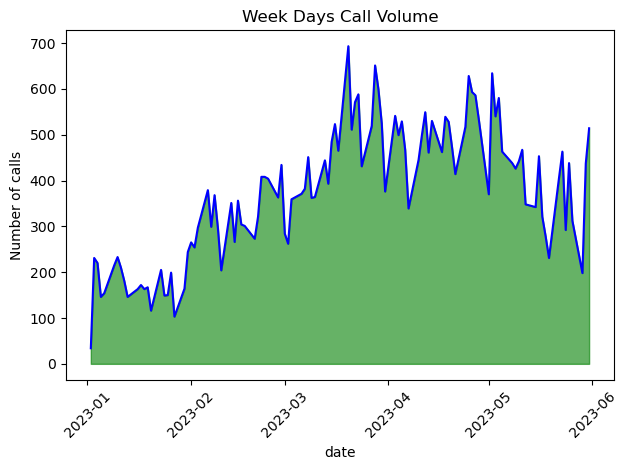

In [97]:
plt.figure()
plt.plot(week_day_calls['date'], week_day_calls['call_count'], color='blue')

plt.fill_between(week_day_calls['date'], week_day_calls['call_count'],color='green', alpha=0.6)

plt.title("Week Days Call Volume")
plt.xlabel("date")
plt.ylabel("Number of calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# WEEKEND TIME DURATION

In [100]:
df5 = df4.copy()

In [102]:
df5 = df5[~df5['day'].isin(['Monday', 'Thursday', 'Friday', 'Wednesday', 'Tuesday'])]

In [104]:
df5.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
802,2023-01-07 10:01:00,Outbound,1.450000,Ray Levesque,Saturday
818,2023-01-07 11:54:00,Outbound,0.666667,Ray Levesque,Saturday
823,2023-01-07 12:16:00,Outbound,1.683333,Ray Levesque,Saturday
824,2023-01-07 12:40:00,Outbound,25.483333,Ray Levesque,Saturday
842,2023-01-07 13:57:00,Outbound,7.433333,Ray Levesque,Saturday


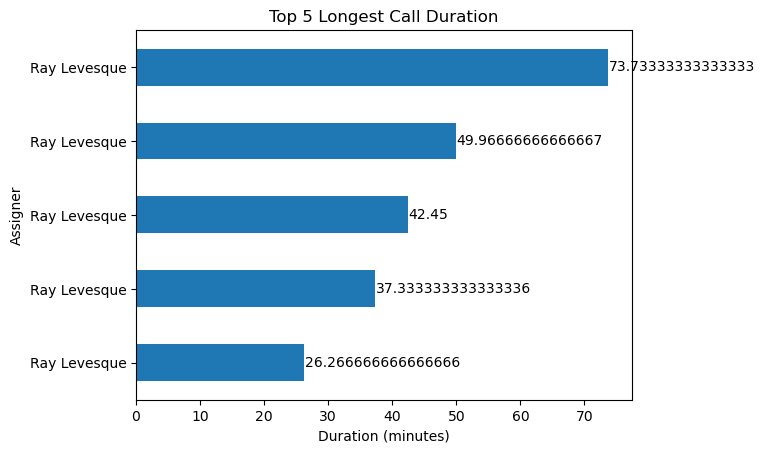

In [106]:
top5 = df5.nlargest(5, "Call duration")

ax = top5.set_index("Activity assigned to")["Call duration"].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v + 0.1, i, str(v), va="center")

plt.title("Top 5 Longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Top 5 Weekend call Assigner

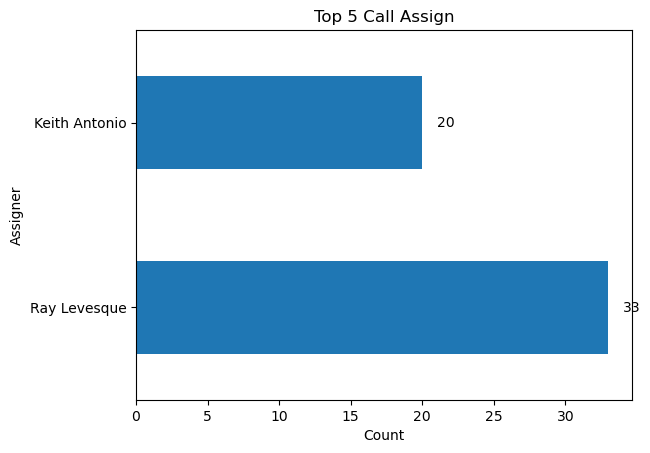

In [111]:
ASSI_COUNT = df5['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Monthly Call Count

In [114]:
df6 = df3.copy()

In [116]:
df6['month'] = df6['Activity date'].dt.month_name()

In [118]:
df6.head()

,Activity date,Call direction,Call duration,Activity assigned to,day,month
15,2023-01-02 10:01:00,NaN,00:31:50,Travis Fleming,Monday,January
16,2023-01-02 10:20:00,NaN,00:04:20,Ray Levesque,Monday,January
17,2023-01-02 13:03:00,NaN,NaN,David Banister,Monday,January
18,2023-01-02 13:19:00,NaN,NaN,David Banister,Monday,January
19,2023-01-02 13:23:00,NaN,NaN,David Banister,Monday,January


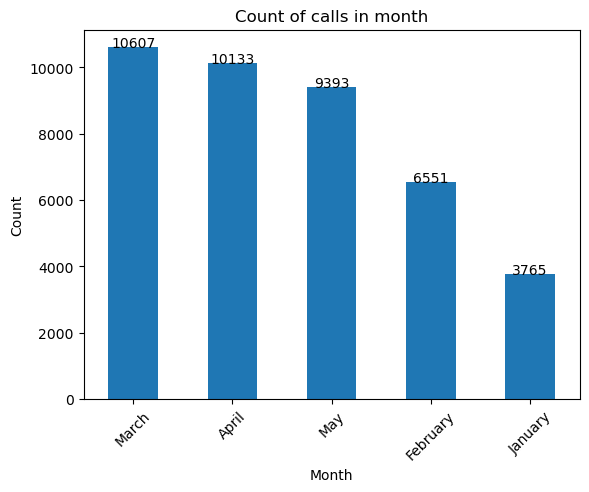

In [120]:
month_counts = df6["month"].value_counts()
month_counts.plot(kind="bar")
ax = month_counts.plot(kind="bar")

for i, v in enumerate(month_counts):
    ax.text(i, v + 1, str(v), ha="center")

plt.title("Count of calls in month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Average Call Duration

In [123]:
df4["Call duration"].mean()

6.20021505376344

In [125]:
df4["Call duration"].median()

1.1166666666666667

# WITHOUT CALL ASSIGNER CALLS

In [128]:
no_assigner_calls = df6[df6["Activity assigned to"].isna()]

In [130]:
no_assigner_calls.info()

<class 'pandas.DataFrame'>
Index: 12 entries, 67 to 2404
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         12 non-null     datetime64[us]
 1   Call direction        0 non-null      str           
 2   Call duration         12 non-null     str           
 3   Activity assigned to  0 non-null      str           
 4   day                   12 non-null     str           
 5   month                 12 non-null     str           
dtypes: datetime64[us](1), str(5)
memory usage: 950.0 bytes


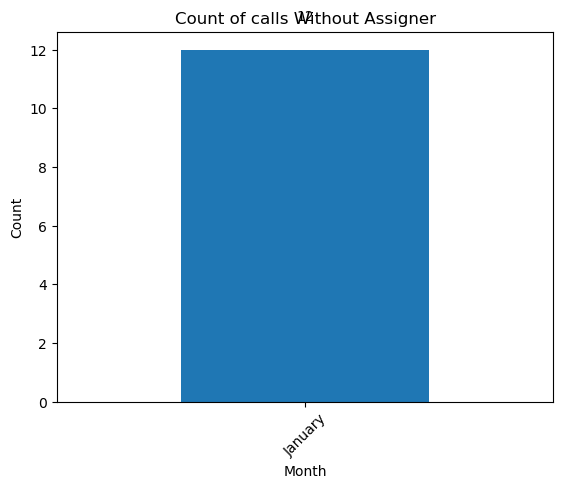

In [132]:
month_counts = no_assigner_calls["month"].value_counts()
month_counts.plot(kind="bar")
ax = month_counts.plot(kind="bar")

for i, v in enumerate(month_counts):
    ax.text(i, v + 1, str(v), ha="center")

plt.title("Count of calls Without Assigner")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# TOP 5 PEAK CALL DATE

In [135]:
df2.head()

,Activity date,Call direction,Call duration,Activity assigned to,date
0,2023-01-01 12:00:00,NaN,00:02:06,Ray Levesque,2023-01-01
1,2023-01-01 16:42:00,NaN,NaN,David Banister,2023-01-01
2,2023-01-01 16:48:00,NaN,NaN,David Banister,2023-01-01
3,2023-01-01 16:54:00,NaN,NaN,David Banister,2023-01-01
4,2023-01-01 16:57:00,NaN,NaN,David Banister,2023-01-01


In [137]:
daily_calls = df.groupby(df2["Activity date"].dt.date).size()

In [139]:
top5 = daily_calls.sort_values(ascending=False).head(5)

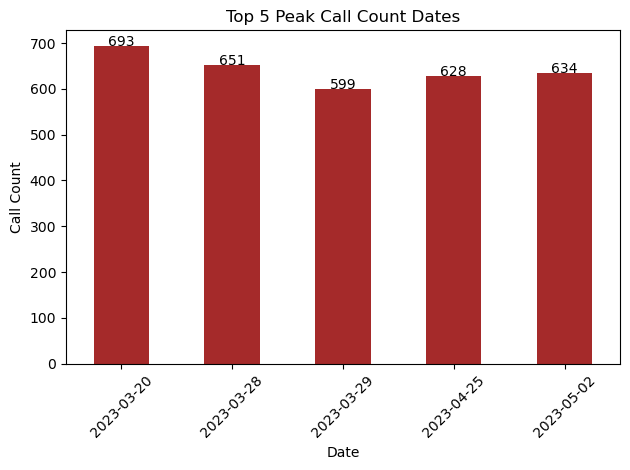

In [141]:
ax = top5.sort_index().plot(kind="bar", color="brown")

for i, v in enumerate(top5.sort_index()):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=10)
    
plt.title("Top 5 Peak Call Count Dates")
plt.xlabel("Date")
plt.ylabel("Call Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()